# 03e — E2.2 Face-Crop EfficientNet-B0 Training

**Experiment:** E2.2 — Full fine-tuning of ImageNet-pretrained EfficientNet-B0 on RetinaFace face crops  
**Purpose:** Isolate face-focused preprocessing relative to E2.1.

This notebook trains and validates only. It never reads the face-crop test split.


## Controlled experimental design

- **Control:** E2.1 fully fine-tuned EfficientNet-B0 on full frames
- **Independent variable:** full RGB frame replaced by a RetinaFace crop
- **Held constant:** architecture, ImageNet initialization, transform, seed, all-layer training, Adam, learning rate 1e-5, weight decay 1e-4, batch size 32, ten epochs and final-epoch checkpoint
- **Face preprocessing:** fixed 15% width/height margin; crops saved at 224×224
- **Validity note:** failed face detections reduce the number of available frames and create a small class imbalance


## 1. Safety and reproducibility controls


In [1]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

SEED = 42
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 0.00001
WEIGHT_DECAY = 0.0001
NUM_WORKERS = 0

CHECKPOINT_NAME = "efficientnet_b0_face_finetuned.pth"
RESULTS_NAME = "efficientnet_b0_face_finetuned_results.json"
PLOT_NAME = "efficientnet_b0_face_finetuned_training.png"

print("E2.2 training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("Seed:", SEED)


E2.2 training enabled: True
Allow checkpoint overwrite: False
Seed: 42


## 2. Imports, paths and clean face-split checks


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TRAIN_DIR = os.path.join(BASE_PATH, "face_dataset", "train")
VAL_DIR = os.path.join(BASE_PATH, "face_dataset", "val")
MODEL_PATH = os.path.join(BASE_PATH, "saved_models", CHECKPOINT_NAME)
RESULTS_PATH = os.path.join(BASE_PATH, "results", RESULTS_NAME)
PLOT_PATH = os.path.join(BASE_PATH, "plots", PLOT_NAME)
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")

for required_path, description in [
    (TRAIN_DIR, "Training directory"),
    (VAL_DIR, "Validation directory"),
    (SPLIT_MANIFEST_PATH, "Video-level split manifest"),
]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"{description} not found: {required_path}")

if RUN_TRAINING and os.path.exists(MODEL_PATH) and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"E2.2 checkpoint already exists: {MODEL_PATH}\n"
        "Set ALLOW_CHECKPOINT_OVERWRITE=True only when replacement is intentional."
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is unavailable; training will run more slowly on CPU.")
print("Training data:", TRAIN_DIR)
print("Validation data:", VAL_DIR)
print("Checkpoint:", MODEL_PATH)


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Training data: /content/drive/MyDrive/deepfake_project/face_dataset/train
Validation data: /content/drive/MyDrive/deepfake_project/face_dataset/val
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_face_finetuned.pth


## 3. ImageNet preprocessing and verified face-crop loaders


In [3]:
weights = EfficientNet_B0_Weights.DEFAULT
transform = weights.transforms()

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

EXPECTED_CLASS_MAPPING = {"fake": 0, "real": 1}
if train_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(f"Unexpected training class mapping: {train_dataset.class_to_idx}")
if val_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(f"Unexpected validation class mapping: {val_dataset.class_to_idx}")

def named_class_counts(dataset):
    counts = Counter(dataset.targets)
    return {
        class_name: counts[class_index]
        for class_name, class_index in dataset.class_to_idx.items()
    }

train_class_counts = named_class_counts(train_dataset)
val_class_counts = named_class_counts(val_dataset)
if train_class_counts != {"fake": 1398, "real": 1342}:
    raise RuntimeError(f"Unexpected training counts: {train_class_counts}")
if val_class_counts != {"fake": 300, "real": 290}:
    raise RuntimeError(f"Unexpected validation counts: {val_class_counts}")

def recover_video_ids(dataset):
    identifiers = set()
    for image_path, _ in dataset.samples:
        stem = os.path.splitext(os.path.basename(image_path))[0]
        if "_frame_" not in stem:
            raise ValueError(f"Cannot recover source-video id from: {image_path}")
        identifiers.add(stem.rsplit("_frame_", 1)[0])
    return identifiers

train_video_ids = recover_video_ids(train_dataset)
val_video_ids = recover_video_ids(val_dataset)
with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as manifest_file:
    split_manifest = json.load(manifest_file)

expected_train_video_ids = {
    os.path.splitext(name)[0]
    for class_splits in split_manifest["classes"].values()
    for name in class_splits["train"]
}
expected_val_video_ids = {
    os.path.splitext(name)[0]
    for class_splits in split_manifest["classes"].values()
    for name in class_splits["val"]
}
if train_video_ids != expected_train_video_ids:
    raise RuntimeError("Training videos do not match the split manifest.")
if val_video_ids != expected_val_video_ids:
    raise RuntimeError("Validation videos do not match the split manifest.")

train_val_overlap = train_video_ids & val_video_ids
if train_val_overlap:
    raise RuntimeError(
        f"Train/validation video overlap: {sorted(train_val_overlap)[:5]}"
    )

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training class counts:", train_class_counts)
print("Validation class counts:", val_class_counts)
print("Training source videos:", len(train_video_ids))
print("Validation source videos:", len(val_video_ids))
print("Train/validation overlapping videos:", len(train_val_overlap))
print("PASS: E2.2 face-crop data validation completed.")


Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Training class counts: {'fake': 1398, 'real': 1342}
Validation class counts: {'fake': 300, 'real': 290}
Training source videos: 280
Validation source videos: 60
Train/validation overlapping videos: 0
PASS: E2.2 face-crop data validation completed.


## 4. Build E2.2 with every parameter trainable


In [4]:
model = efficientnet_b0(weights=weights)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(DEVICE)

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
if not all(parameter.requires_grad for parameter in model.parameters()):
    raise RuntimeError("Every E2.2 parameter must be trainable.")
if trainable_parameters != total_parameters:
    raise RuntimeError("Trainable and total parameter counts do not match.")

print(model.classifier)
print("Trainable parameters:", trainable_parameters)
print("Total parameters:", total_parameters)
print("PASS: all E2.2 parameters are trainable.")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)
Trainable parameters: 4010110
Total parameters: 4010110
PASS: all E2.2 parameters are trainable.


## 5. Train and save the final E2.2 checkpoint

The final-epoch checkpoint policy deliberately matches E2.1. The best validation epoch is recorded separately but is not substituted at evaluation.


Epoch [1/10], Loss: 0.6629, Validation Accuracy: 60.51%
Epoch [2/10], Loss: 0.5900, Validation Accuracy: 67.46%
Epoch [3/10], Loss: 0.5236, Validation Accuracy: 73.05%
Epoch [4/10], Loss: 0.4510, Validation Accuracy: 78.14%
Epoch [5/10], Loss: 0.3844, Validation Accuracy: 81.19%
Epoch [6/10], Loss: 0.3314, Validation Accuracy: 84.58%
Epoch [7/10], Loss: 0.2887, Validation Accuracy: 85.93%
Epoch [8/10], Loss: 0.2508, Validation Accuracy: 87.12%
Epoch [9/10], Loss: 0.2369, Validation Accuracy: 86.61%
Epoch [10/10], Loss: 0.2120, Validation Accuracy: 87.46%
Final-epoch model saved to: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_face_finetuned.pth
Results saved to: /content/drive/MyDrive/deepfake_project/results/efficientnet_b0_face_finetuned_results.json
Best validation epoch: 10
Best validation accuracy: 87.46%


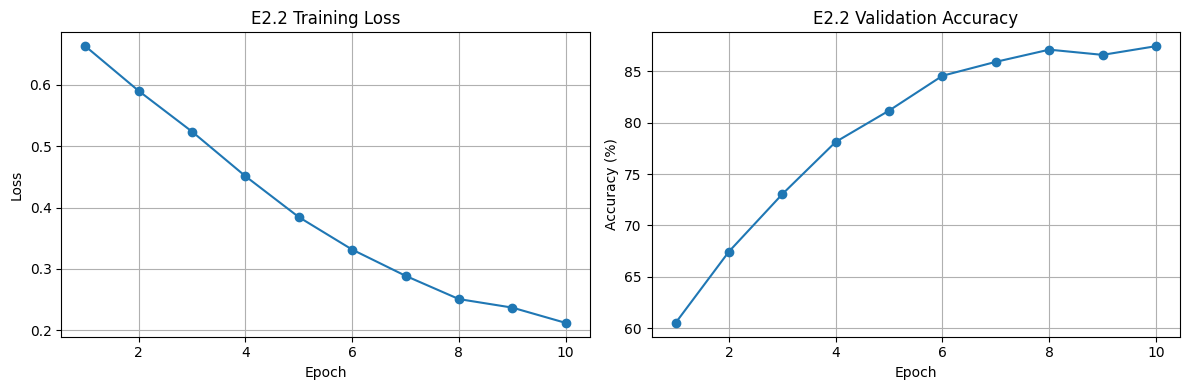

Training plot saved to: /content/drive/MyDrive/deepfake_project/plots/efficientnet_b0_face_finetuned_training.png


In [5]:
if RUN_TRAINING:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    train_losses = []
    val_accuracies = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        train_losses.append(average_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                predictions = model(images).argmax(dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        validation_accuracy = 100.0 * correct / total
        val_accuracies.append(validation_accuracy)
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.4f}, "
            f"Validation Accuracy: {validation_accuracy:.2f}%"
        )

    best_epoch_index = int(np.argmax(val_accuracies))
    best_epoch = best_epoch_index + 1
    best_val_accuracy = val_accuracies[best_epoch_index]

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(PLOT_PATH), exist_ok=True)
    torch.save(model.state_dict(), MODEL_PATH)
    print("Final-epoch model saved to:", MODEL_PATH)

    results = {
        "experiment": "E2.2",
        "research_question": "Does RetinaFace cropping improve the E2.1 full-fine-tuning regimen?",
        "model": "EfficientNet-B0 Fine-Tuned on Face Crops",
        "training_strategy": "Full fine-tuning of all parameters",
        "checkpoint_strategy": "final epoch",
        "transfer_learning": True,
        "pretrained_on": "ImageNet",
        "seed": SEED,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "optimizer": "Adam over all model parameters",
        "loss_function": "CrossEntropyLoss",
        "preprocessing": "RetinaFace crop saved 224x224 with 15% margin; EfficientNet_B0_Weights.DEFAULT.transforms()",
        "face_crop_saved_size": [224, 224],
        "face_margin_ratio": 0.15,
        "class_mapping": train_dataset.class_to_idx,
        "training_class_counts": train_class_counts,
        "validation_class_counts": val_class_counts,
        "training_source_videos": len(train_video_ids),
        "validation_source_videos": len(val_video_ids),
        "train_validation_video_overlap": len(train_val_overlap),
        "trainable_parameters": trainable_parameters,
        "total_parameters": total_parameters,
        "training_losses": train_losses,
        "validation_accuracies": val_accuracies,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "final_val_accuracy": val_accuracies[-1],
        "final_training_loss": train_losses[-1],
        "checkpoint_path": MODEL_PATH,
        "split_manifest_path": SPLIT_MANIFEST_PATH,
    }
    with open(RESULTS_PATH, "w", encoding="utf-8") as results_file:
        json.dump(results, results_file, indent=4)

    print("Results saved to:", RESULTS_PATH)
    print("Best validation epoch:", best_epoch)
    print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

    epochs_axis = list(range(1, NUM_EPOCHS + 1))
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, train_losses, marker="o")
    axes[0].set_title("E2.2 Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
    axes[1].plot(epochs_axis, val_accuracies, marker="o")
    axes[1].set_title("E2.2 Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    print("Training plot saved to:", PLOT_PATH)
else:
    print("Training skipped safely.")
    print("Set RUN_TRAINING=True only when intentionally training E2.2.")


## 6. Next notebook

Use `04e_E22_FFPP_Evaluation.ipynb` with `efficientnet_b0_face_finetuned.pth` on the untouched face-crop test split. Never substitute the E2.1 full-frame checkpoint.
